<a href="https://colab.research.google.com/github/silvatria/PCVK_Ganjil_2026/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [6]:
# D. PRAKTIKUM FILTER
# 2

def convolution2d(image, kernel, stride, padding):
    # 1. Mengambil dimensi citra dan kernel
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # 2. Menambahkan padding (zero padding) pada citra masukan
    # np.pad akan menambahkan baris/kolom berisi nilai 0 di sekeliling gambar
    padded_image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)

    # 3. Menghitung dimensi citra keluaran (output) setelah konvolusi
    output_height = int(((img_height - kernel_height + 2 * padding) / stride) + 1)
    output_width = int(((img_width - kernel_width + 2 * padding) / stride) + 1)

    # 4. Membuat matriks kosong untuk menampung hasil konvolusi
    output_image = np.zeros((output_height, output_width))

    # 5. Proses pergeseran kernel (Konvolusi)
    for y in range(output_height):
        for x in range(output_width):
            # Menentukan area region of interest (ROI) pada gambar yang sedang diproses
            y_start = y * stride
            y_end = y_start + kernel_height
            x_start = x * stride
            x_end = x_start + kernel_width

            image_patch = padded_image[y_start:y_end, x_start:x_end]

            # Operasi perkalian elemen demi elemen dan penjumlahan total nilai (dot product)
            output_image[y, x] = np.sum(image_patch * kernel)

    return output_image

img = cv.imread('/content/drive/MyDrive/2C/PCVK/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#image sharpen
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])
convolution2d(img_gray,kernel_sharpen,1,2)



array([[   0., -145.,  -56., ..., -153., -177.,    0.],
       [-145.,  553.,  -15., ...,  326.,  607., -177.],
       [-116.,  257.,  179., ...,  249.,  218., -125.],
       ...,
       [-156.,  487.,  262., ...,  159.,  183.,  -69.],
       [ -11., -112., -110., ...,  -71.,  -53.,   -4.],
       [   0.,  -11.,  -11., ...,   -4.,   -4.,    0.]])

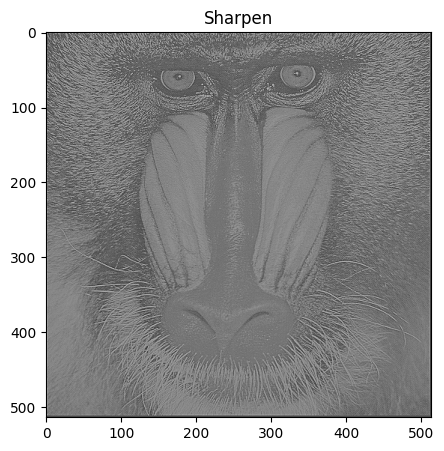

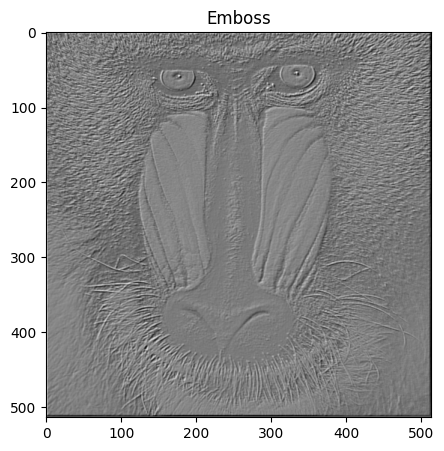

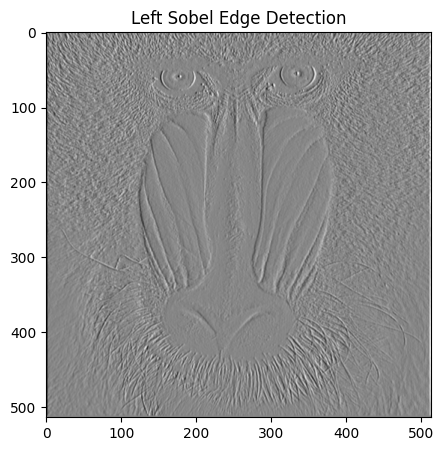

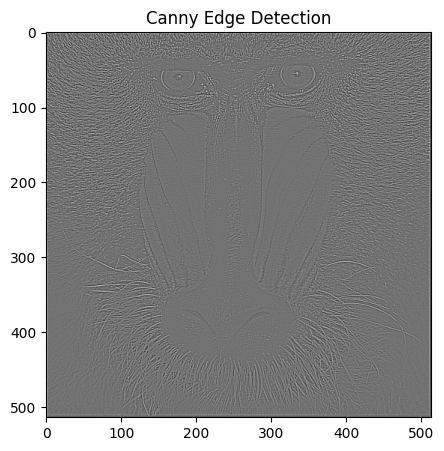

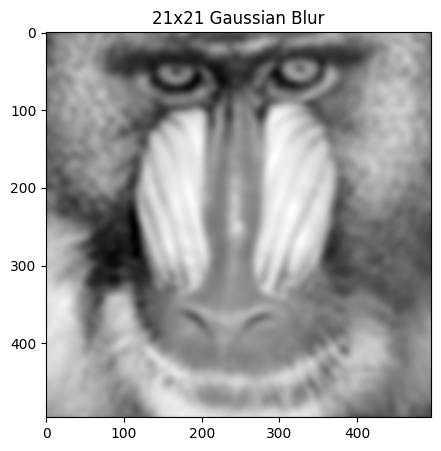

In [7]:
# # D. PRAKTIKUM FILTER
# 3

# A. Sharpen
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

# B. Emboss
kernel_emboss = np.array([[-2, -1, 0],
                          [-1,  1, 1],
                          [ 0,  1, 2]])

# C. Left Sobel Edge Detection
kernel_sobel_left = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])

# D. Canny Edge Detection (Laplacian/Edge Enhance kernel pada tabel)
kernel_canny = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]])

# E. 21x21 Gaussian Blur
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian = gaussian_kernel @ gaussian_kernel.transpose()

# Proses filter menggunakan fungsi konvolusi manual Anda
res_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=2)
res_emboss  = convolution2d(img_gray, kernel_emboss, stride=1, padding=2)
res_sobel   = convolution2d(img_gray, kernel_sobel_left, stride=1, padding=2)
res_canny   = convolution2d(img_gray, kernel_canny, stride=1, padding=2)
res_blur    = convolution2d(img_gray, kernel_gaussian, stride=1, padding=2)

# Fungsi pembantu untuk menampilkan citra sesuai format gambar tugas Anda
def tampilkan_hasil(gambar_hasil, judul):
    plt.figure(figsize=(5,5))
    plt.imshow(gambar_hasil, cmap='gray')
    plt.title(judul)
    plt.show()

# Menampilkan masing-masing output
tampilkan_hasil(res_sharpen, "Sharpen")
tampilkan_hasil(res_emboss, "Emboss")
tampilkan_hasil(res_sobel, "Left Sobel Edge Detection")
tampilkan_hasil(res_canny, "Canny Edge Detection")
tampilkan_hasil(res_blur, "21x21 Gaussian Blur")


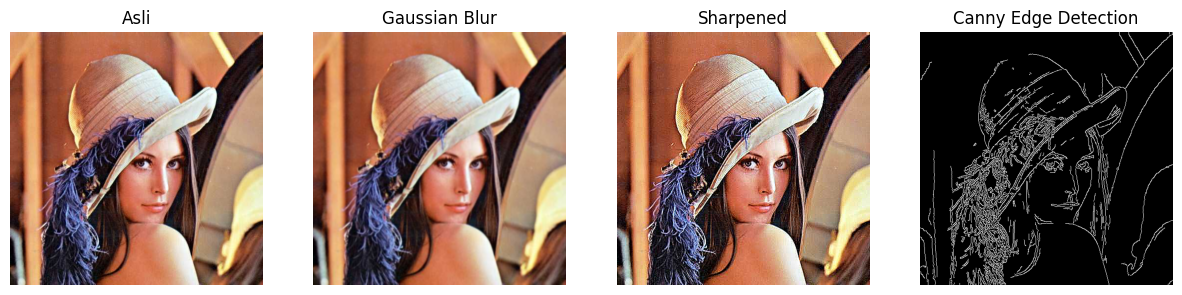

In [11]:
# E. FILTER LIBRARY DAN FILTER MODERN
# Percobaan 1

# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/2C/PCVK/Images/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])


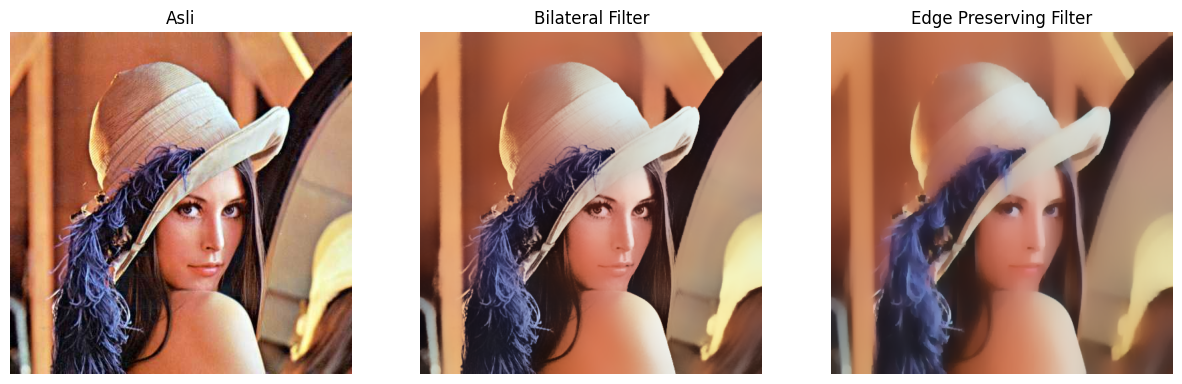

In [12]:
# E. FILTER LIBRARY DAN FILTER MODERN
# Percobaan 2

# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])


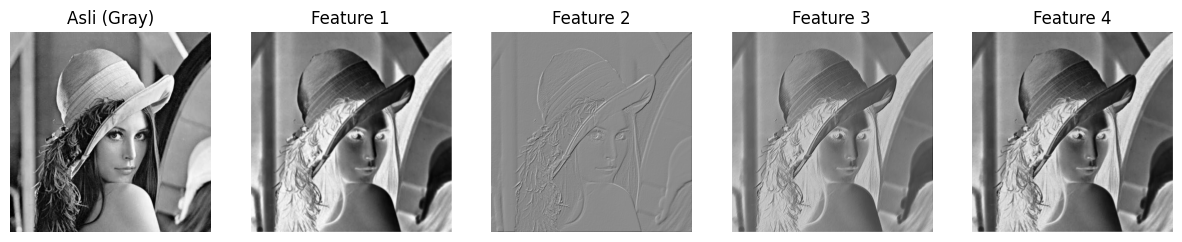

In [13]:
# E. FILTER LIBRARY DAN FILTER MODERN
# Percobaan 3

#Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])


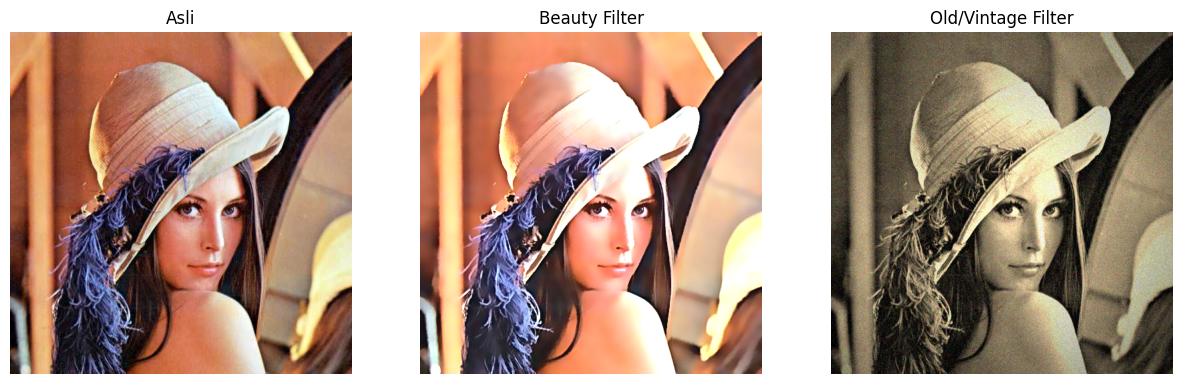

In [21]:
# E. FILTER LIBRARY DAN FILTER MODERN
# Percobaan 4

# ==================
# 1. Beauty Filter
# ==================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)


# =====================
# 2. Old/Vintage Filter
# =====================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)


show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])




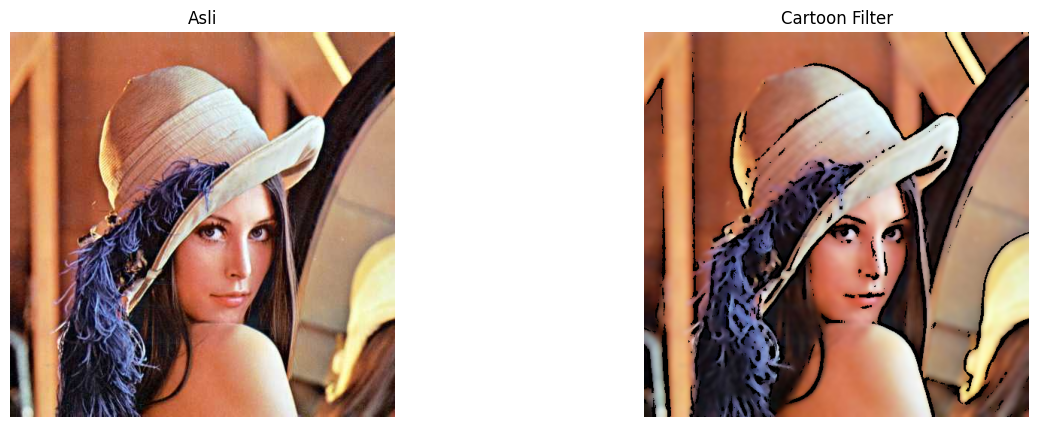

In [22]:
# E. FILTER LIBRARY DAN FILTER MODERN
# Percobaan 5

#Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                            cv.ADAPTIVE_THRESH_MEAN_C,
                            cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])


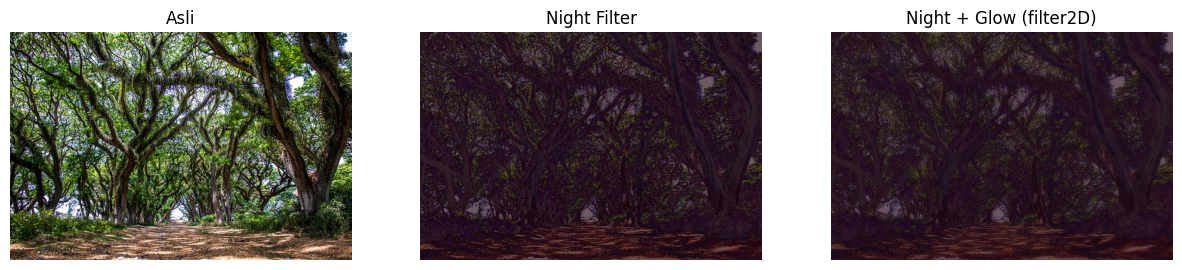

In [26]:
# E. FILTER LIBRARY DAN FILTER MODERN
# Percobaan 6
# Night Filter
img = cv.imread("/content/drive/MyDrive/2C/PCVK/Images/djawatan.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100)) # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])


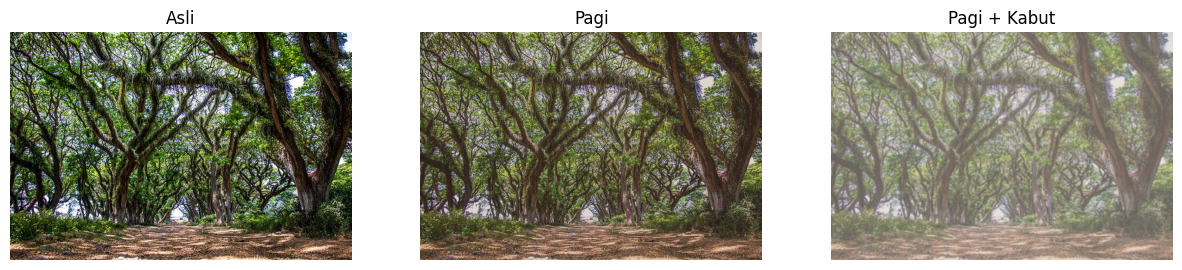

In [27]:
# E. FILTER LIBRARY DAN FILTER MODERN
# Percobaan 7

#Filter Suasana pagi dan Kabut
# ==============================
# Step 1: Kurangi kontras & cerahkan
# ==============================
alpha = 0.9    # contrast
beta = 20      # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ===============================================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ===============================================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ========================================================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ========================================================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])


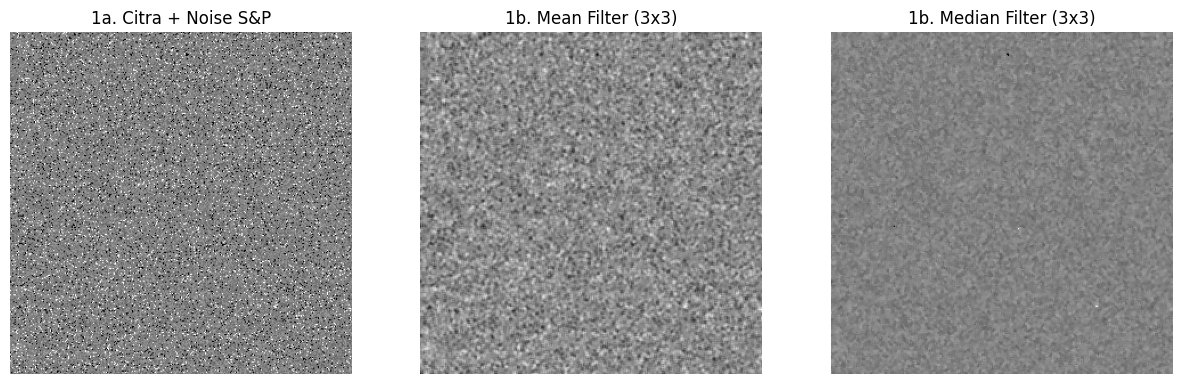

In [28]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# =====================================================================
# KODE PENDUKUNG: Membaca Gambar Masukan
# =====================================================================
# Membaca gambar asli (pastikan path file sesuai dengan di Drive Anda)
img = cv.imread('/content/drive/MyDrive/Polinema/Kuliah/PCVK/Images/mandrill.tiff')
if img is None:
    # Fallback jika file tiff tidak ada, membuat dummy image agar kode tidak crash
    img = np.random.randint(80, 180, (300, 300, 3), dtype=np.uint8)

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# =====================================================================
# TUGAS 1: Perbandingan Mean Filter vs Median Filter pada Noise S&P
# =====================================================================

# a. Membuat fungsi untuk menambahkan noise Salt and Pepper
def add_salt_and_pepper(image, salt_prob, pepper_prob):
    noisy_image = np.copy(image)
    # Salt (Bintik Putih)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords)] = 255

    # Pepper (Bintik Hitam)
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords)] = 0
    return noisy_image

# Tambah noise ke gambar grayscale
img_noisy = add_salt_and_pepper(img_gray, salt_prob=0.05, pepper_prob=0.05)

# b. Terapkan Mean Filter (3x3) dan Median Filter (3x3)
mean_3x3 = cv.blur(img_noisy, (3, 3))
median_3x3 = cv.medianBlur(img_noisy, 3)

# Menampilkan hasil Tugas 1
show_side_by_side([img_noisy, mean_3x3, median_3x3],
                  ["1a. Citra + Noise S&P", "1b. Mean Filter (3x3)", "1b. Median Filter (3x3)"])


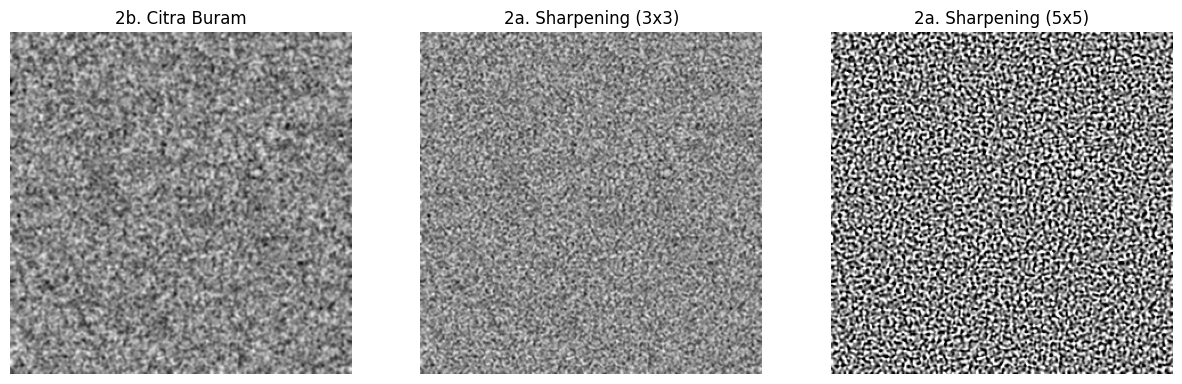

In [30]:
# =====================================================================
# TUGAS 2: Pemilihan Ukuran Kernel Terbaik untuk Sharpening
# =====================================================================

# Membuat gambar agak buram (blurry) terlebih dahulu sebagai input
img_blurry = cv.GaussianBlur(img_gray, (5, 5), 0)

# a. Buat kernel penajaman ukuran 3x3 dan 5x5
kernel_sharpen_3x3 = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])

kernel_sharpen_5x5 = np.array([[-1, -1, -1, -1, -1],
                               [-1, -1, -1, -1, -1],
                               [-1, -1, 25, -1, -1],
                               [-1, -1, -1, -1, -1],
                               [-1, -1, -1, -1, -1]])

# b. Terapkan pada citra buram
res_sharpen_3x3 = cv.filter2D(img_blurry, -1, kernel_sharpen_3x3)
res_sharpen_5x5 = cv.filter2D(img_blurry, -1, kernel_sharpen_5x5)

# Menampilkan hasil Tugas 2
show_side_by_side([img_blurry, res_sharpen_3x3, res_sharpen_5x5],
                  ["2b. Citra Buram", "2a. Sharpening (3x3)", "2a. Sharpening (5x5)"])

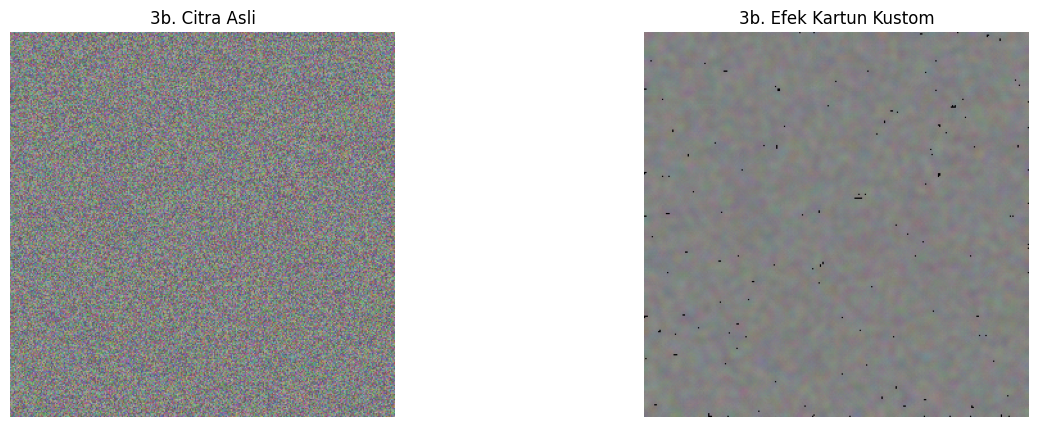

In [31]:
# =====================================================================
# TUGAS 3: Tugas Kreasi Filter Kartun Sederhana
# =====================================================================

# a. Membuat fungsi kustom kartun(image)
def kartun(image):
    # Pastikan memproses warna/gray secara kondisional
    if len(image.shape) == 3:
        gray_local = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    else:
        gray_local = image

    # Step 1: Deteksi garis tepi (Adaptive Thresholding)
    gray_blur = cv.medianBlur(gray_local, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)

    # Step 2: Penghalusan warna (Bilateral Filter)
    color_smooth = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # Step 3: Penggabungan menggunakan operasi logika mask
    cartoon_img = cv.bitwise_and(color_smooth, color_smooth, mask=edges)
    return cartoon_img

# b. Tampilkan hasil citra asli dan kartun bersebelahan
# Menggunakan citra berwarna 'img' agar efek filter kartun lebih terlihat nyata
hasil_kartun = kartun(img)
show_side_by_side([img, hasil_kartun], ["3b. Citra Asli", "3b. Efek Kartun Kustom"])